# EXPLORATORY DATA ANALYSIS AND LEAD SCORING MODEL: Enpal Heat Pump Conversion Prediction
Dataset: 10,000 customer inquiries
Goal: Understanding patterns driving heat pump purchases in Germany

Key Analysis Areas:
1. Data Quality & Missing Values
2. Class Imbalance Assessment
3. Temporal Patterns (seasonality, trends via temporal fields)
4. Property Characteristics (home age, size, current heating)
5. Customer Demographics (income, region)
6. Sales Lead Quality (channel, contact attempts)
7. Feature Relationships & Correlations
8. Conversion Drivers

## Step 0: Setup and Import

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer




import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [34]:
#plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Step 1: Data preprocessing and analysis

In [43]:
def load_conversion_df(df, category_col, target_col='converted'):
    """
    Groups data by category and calculates conversions, leads, and rates.
    """
    # Group and aggregate
    dist_df = df.groupby(category_col)[target_col].agg(['sum', 'count', 'mean'])
    
    # Apply multipliers and rename
    dist_df['mean'] = dist_df['mean'] * 100
    dist_df.columns = ['Conversions', 'Leads', 'Conv_Rate_%']
    
    # Sort for the print output (highest first)
    return dist_df.sort_values('Conv_Rate_%', ascending=False)

def plot_categorical_conversion(dist_df, category_name, avg_rate, plot_dir="plots"):
    """
    Creates a horizontal bar chart and saves it.
    """
    # Sort ascending for the horizontal bar chart (highest at the top)
    plot_data = dist_df.sort_values('Conv_Rate_%', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define colors based on average
    colors = ['#2ECC71' if x > avg_rate else '#E74C3C' for x in plot_data['Conv_Rate_%']]
    
    # Create bars
    bars = ax.barh(range(len(plot_data)), plot_data['Conv_Rate_%'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    # Labels and Titles
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data.index, fontsize=11)
    ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Conversion Rate by {category_name}', fontsize=15, fontweight='bold', pad=20)
    
    # Average Line
    ax.axvline(x=avg_rate, color='black', linestyle='--', linewidth=2, alpha=0.5, 
               label=f'Overall Avg ({avg_rate:.1f}%)')
    
    # Add text labels to bars
    for bar, rate in zip(bars, plot_data['Conv_Rate_%']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                f'{rate:.2f}%', va='center', fontsize=10, fontweight='bold')
    
    ax.legend()
    plt.tight_layout()
    
    # Save logic
    safe_name = category_name.lower().replace(" ", "_")
    filename = f"{plot_dir}/dist_{safe_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    print(f"Saved: {filename}")

def plot_dual_axis_trend(df, vol_col='count', rate_col='mean', title='Lead Volume and Conversion Rate', save_path=None):
    """
    Creates a dual-axis line chart for volume (left) and conversion rate (right).
    
    Parameters:
    - df: The DataFrame (expects time/categories in the index)
    - vol_col: Column name for the volume/count
    - rate_col: Column name for the rate/percentage
    - title: Title of the chart
    - save_path: If provided, saves the figure to this path
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # 1. Plot Lead Volume on ax1 (Left Axis)
    color_vol = "#EE170B" # Darker blue/grey for volume
    ax1.set_xlabel('Timeline', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Lead Volume (Count)', color=color_vol, fontsize=11, fontweight='bold')
    line1 = ax1.plot(df.index, df[vol_col], color=color_vol, linewidth=2.5, label="Volume", marker='o', markersize=4)
    ax1.tick_params(axis='y', labelcolor=color_vol)
    ax1.grid(True, alpha=0.2)

    # 2. Create twin axis for Conversion Rate (Right Axis)
    ax2 = ax1.twinx() 
    color_rate = '#27AE60' # Green for conversion
    ax2.set_ylabel('Conversion Rate (%)', color=color_rate, fontsize=11, fontweight='bold')
    line2 = ax2.plot(df.index, df[rate_col], color=color_rate, linewidth=2.5, label="Conv. Rate", marker='s', markersize=4)
    ax2.tick_params(axis='y', labelcolor=color_rate)

    # 3. Combine Legends
    # Because there are two axes, we merge their labels into one box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True)

    # 4. Styling
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()

    # 5. Save and Show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        
    plt.show()
    plt.close()
    
    
import matplotlib.pyplot as plt

def plot_numerical_distribution(df, col_name, title_name, target_col='converted', bins=40, is_currency=False, plot_dir="plots"):
    """
    Creates a dual-histogram to compare distributions of a numerical variable 
    based on conversion status.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Split data
    df_not_conv = df[df[target_col] == 0][col_name].dropna()
    df_conv = df[df[target_col] == 1][col_name].dropna()
    
    # Plot Histograms
    ax.hist([df_not_conv, df_conv], bins=bins, label=['Not Converted', 'Converted'], 
            color=['#E74C3C', '#2ECC71'], alpha=0.6, edgecolor='black', density=False)
    
    # Formatting Labels
    unit = " (EUR)" if is_currency else ""
    ax.set_xlabel(f'{title_name}{unit}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{title_name} Distribution by Conversion Status', fontsize=15, fontweight='bold', pad=20)
    
    # Add Median Lines
    med_not = df_not_conv.median()
    med_conv = df_conv.median()
    
    prefix = "€" if is_currency else ""
    suffix = "" if not is_currency else ""
    
    ax.axvline(med_not, color='#C0392B', linestyle='--', linewidth=2, 
               label=f'Not Conv Median: {prefix}{med_not:,.0f}{suffix}')
    ax.axvline(med_conv, color='#27AE60', linestyle='--', linewidth=2, 
               label=f'Converted Median: {prefix}{med_conv:,.0f}{suffix}')
    
    # Currency Formatter (e.g., 50000 -> €50K)
    if is_currency:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}K'))
    
    ax.legend()
    plt.tight_layout()
    
    # Save Logic
    safe_name = col_name.lower().replace(" ", "_")
    filename = f"{plot_dir}/dist_num_{safe_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    print(f"Saved: {filename}")


### 1.DATA LOADING AND INITIAL INSPECTION

In [36]:
csv_path = 'dataset/heat_pump_conversion_dataset.csv'
plot_dir = "plots"
df = pd.read_csv(
    csv_path,
    na_values=["", " ", "NA", "N/A", "null", "None"]
)

print("Dataframe shape:", df.shape)
print("Dataframe columns:", df.columns.tolist())
print("Dataframe data types:", df.dtypes)
print("Dataframe statistics:", df.describe())

Dataframe shape: (10000, 13)
Dataframe columns: ['inquiry_date', 'house_age', 'heating_system', 'house_size_sqm', 'num_rooms', 'household_income', 'postal_region', 'marketing_channel', 'contact_attempts', 'property_value', 'day_of_week', 'energy_consumption_kwh', 'converted']
Dataframe data types: inquiry_date               object
house_age                  object
heating_system             object
house_size_sqm            float64
num_rooms                   int64
household_income          float64
postal_region              object
marketing_channel          object
contact_attempts            int64
property_value            float64
day_of_week                object
energy_consumption_kwh    float64
converted                   int64
dtype: object
Dataframe statistics:        house_size_sqm     num_rooms  household_income  contact_attempts  \
count    10000.000000  10000.000000      10000.000000       10000.00000   
mean       150.311300      5.464000      64358.510000           3.50600  

In [37]:
# Target sanity
df["converted"] = df["converted"].astype(int)
# Calculate global average once
conversion_rate = df["converted"].mean() * 100  # %

print(f"base rate of conversion in the dataset: {conversion_rate}%")
df.head()

base rate of conversion in the dataset: 5.0%


,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,NaN,0


In [38]:
#numerical features summary
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('converted')
print(df[numerical_cols].describe().round(2))

       house_size_sqm  num_rooms  household_income  contact_attempts  \
count        10000.00   10000.00          10000.00          10000.00   
mean           150.31       5.46          64358.51              3.51   
std             39.74       1.71          26103.32              1.80   
min             60.00       2.00          30000.00              1.00   
25%            123.00       4.00          45500.00              2.00   
50%            150.00       6.00          59450.00              3.00   
75%            177.00       7.00          77200.00              5.00   
max            293.00       8.00         200000.00             10.00   

       property_value  energy_consumption_kwh  
count        10000.00                 8108.00  
mean        375279.30                15074.08  
std         111132.47                 4903.45  
min          13000.00                 5000.00  
25%         300000.00                11624.25  
50%         375000.00                15166.50  
75%         450

The target class has high imbalance. Out of 10000 data points, only 500 is converted. 

In [39]:
# Missing values
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame("missing_rate").head(10))

df["energy_missing"] = df["energy_consumption_kwh"].isna().astype(int)
display(df.groupby("energy_missing")["converted"].agg(["mean","count"]))

,missing_rate
energy_consumption_kwh,0.1892
house_age,0.0000
heating_system,0.0000
house_size_sqm,0.0000
inquiry_date,0.0000
num_rooms,0.0000
household_income,0.0000
marketing_channel,0.0000
postal_region,0.0000
contact_attempts,0.0000


,mean,count
energy_missing,,
0,0.057474,8108
1,0.017970,1892


#### Handling inquiry_date and temporal analysis

Saved: plots/weekly_trend.png


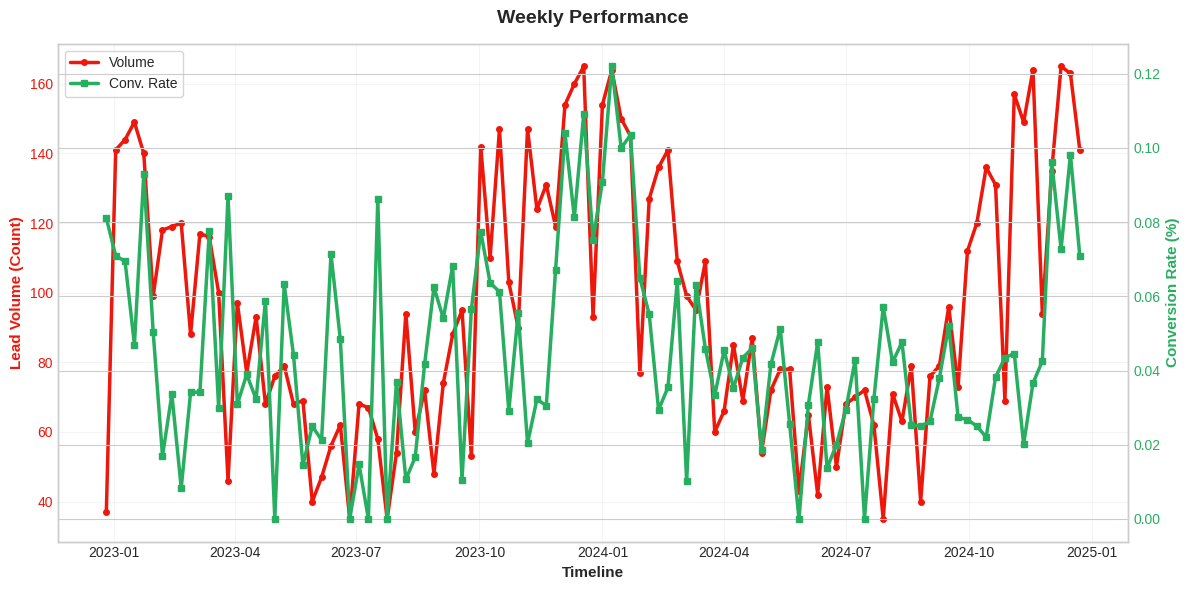

Saved: plots/monthly_trend.png


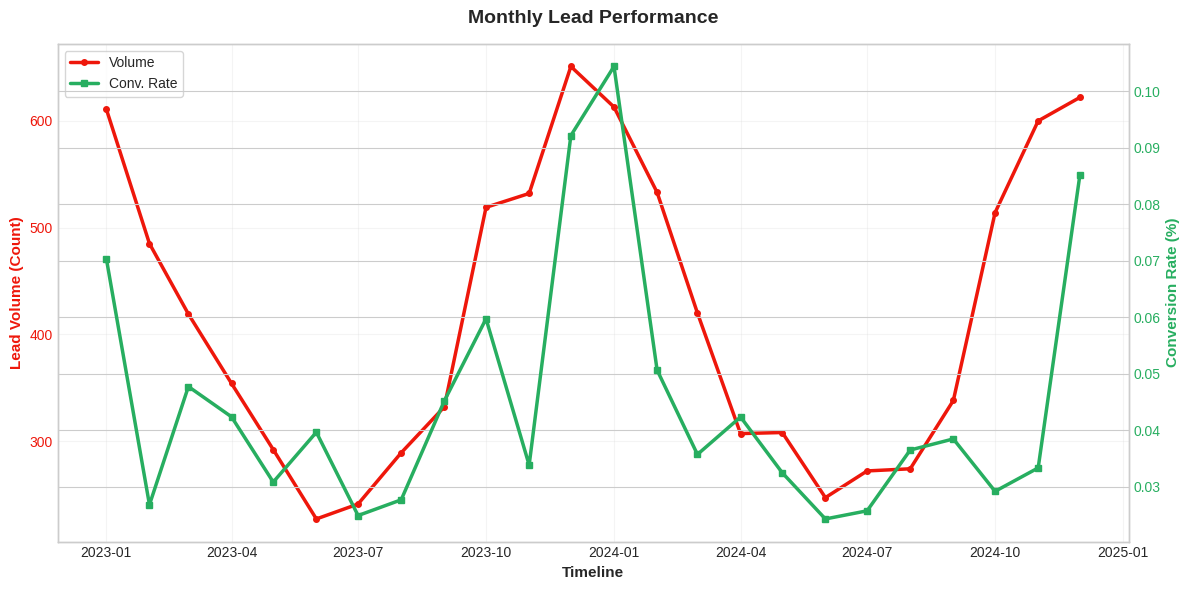

Saved: plots/quarterly_trend.png


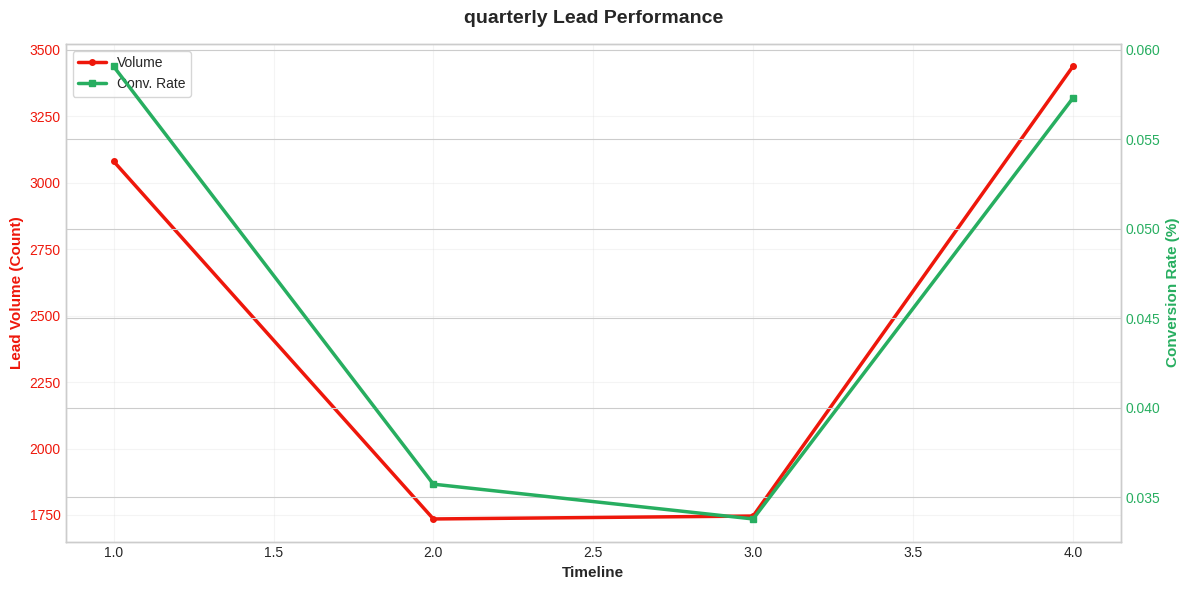

In [44]:
df['inquiry_date'] = pd.to_datetime(df['inquiry_date'])

tmp = df.dropna(subset=["inquiry_date"]).copy()
tmp["week"] = tmp["inquiry_date"].dt.to_period("W").dt.start_time
tmp["month"] = tmp["inquiry_date"].dt.to_period("M").dt.start_time
tmp["quarter"] = tmp["inquiry_date"].dt.quarter

weekly = tmp.groupby("week")["converted"].agg(["mean","count"])
monthly = tmp.groupby("month")["converted"].agg(["mean","count"])
quarterly = tmp.groupby("quarter")["converted"].agg(["mean","count"])


plot_dual_axis_trend(weekly, vol_col='count', rate_col='mean', title="Weekly Performance", save_path=f'{plot_dir}/weekly_trend.png')

# For Monthly Data
plot_dual_axis_trend(monthly, title="Monthly Lead Performance", save_path=f'{plot_dir}/monthly_trend.png')
# For Monthly Data
plot_dual_axis_trend(quarterly, title="quarterly Lead Performance", save_path=f'{plot_dir}/quarterly_trend.png')


#### Analysing Property Characteristics

             Conversions  Leads  Conv_Rate_%
house_age                                   
>30 years            213   3094         6.88
10-30 years          215   4959         4.34
<10 years             72   1947         3.70


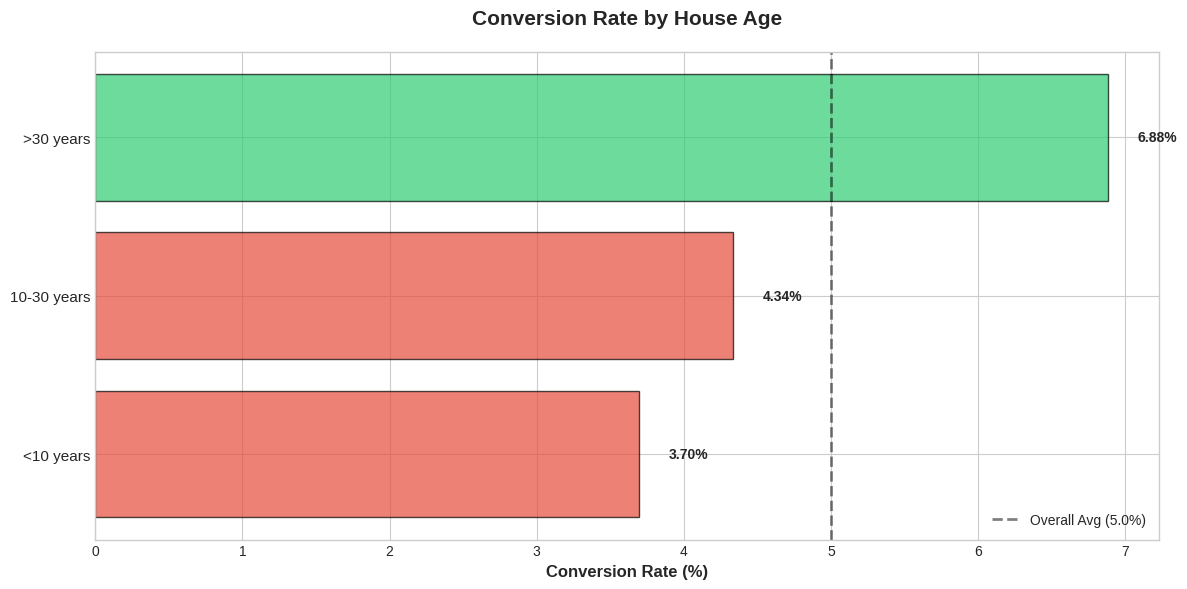

Saved: plots/dist_house_age.png


In [45]:
# 1. House Age
house_age_stats = prepare_conversion_df(df, 'house_age')
print(house_age_stats.round(2))
plot_categorical_conversion(house_age_stats, 'House Age', overall_avg)

                Conversions  Leads  Conv_Rate_%
heating_system                                 
Oil                     248   2485         9.98
Electric                 80   1442         5.55
Gas                     160   5058         3.16
District                 12   1015         1.18


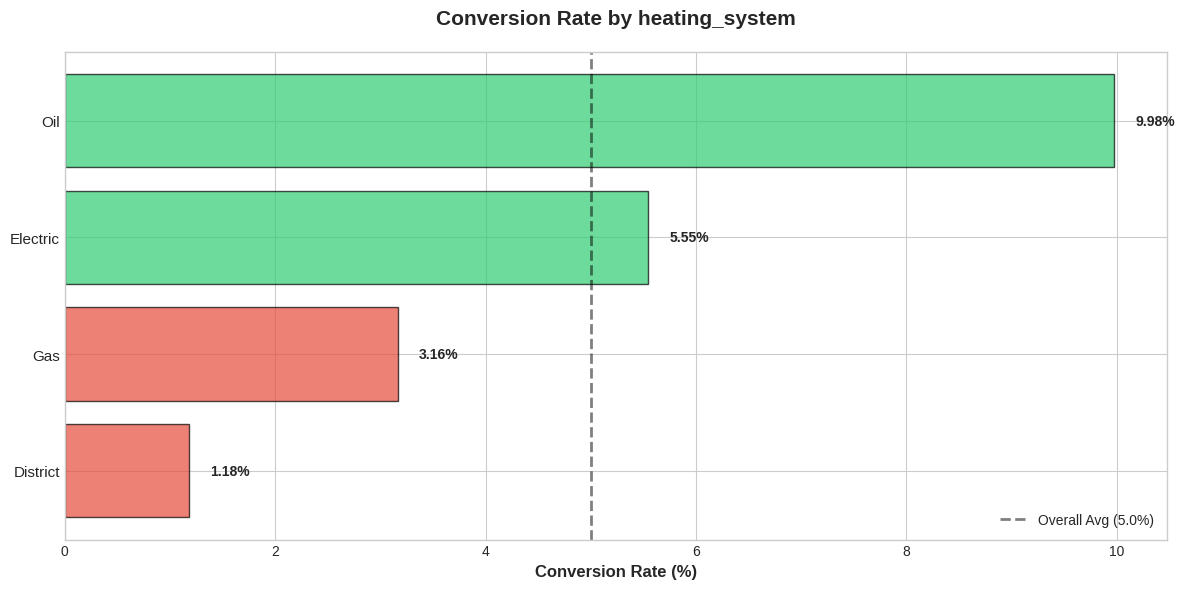

Saved: plots/dist_heating_system.png


In [46]:
# 2.Heating System
heating_system_stats = prepare_conversion_df(df, 'heating_system')
print(heating_system_stats.round(2))
plot_categorical_conversion(heating_system_stats, 'heating_system', overall_avg)


Not Converted - Median: €375,000, Mean: €375,280
Converted     - Median: €374,000, Mean: €375,258
0.001     64999.0
0.010    121990.0
0.990    638000.0
0.999    744007.0
Name: property_value, dtype: float64


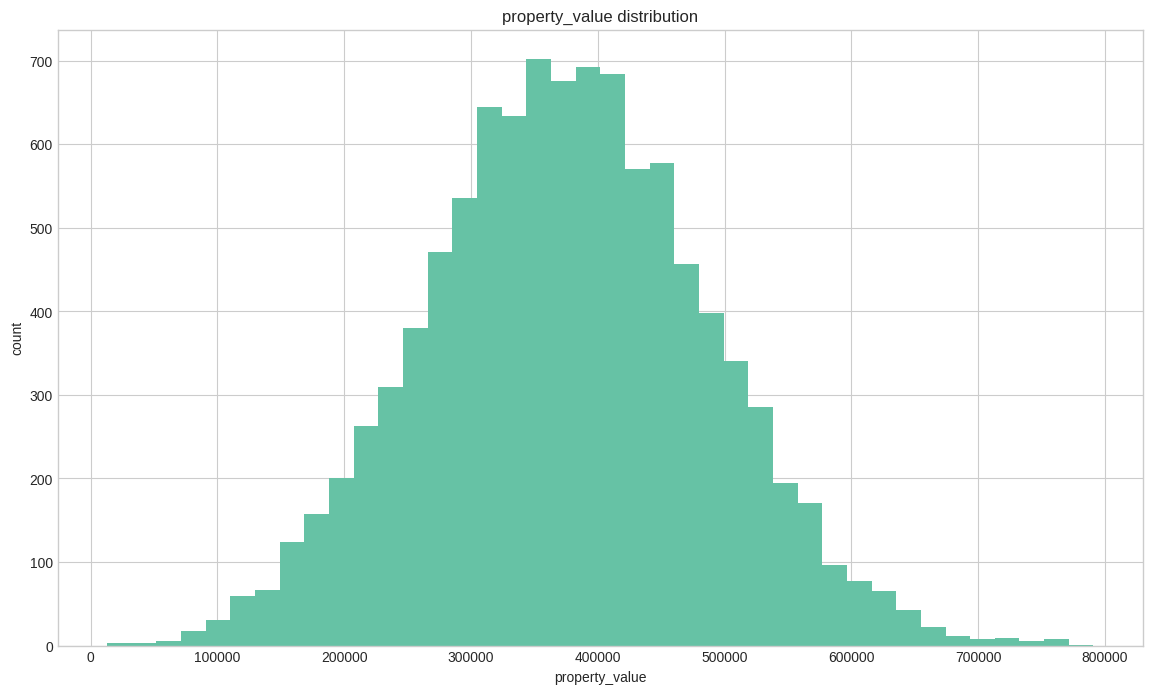

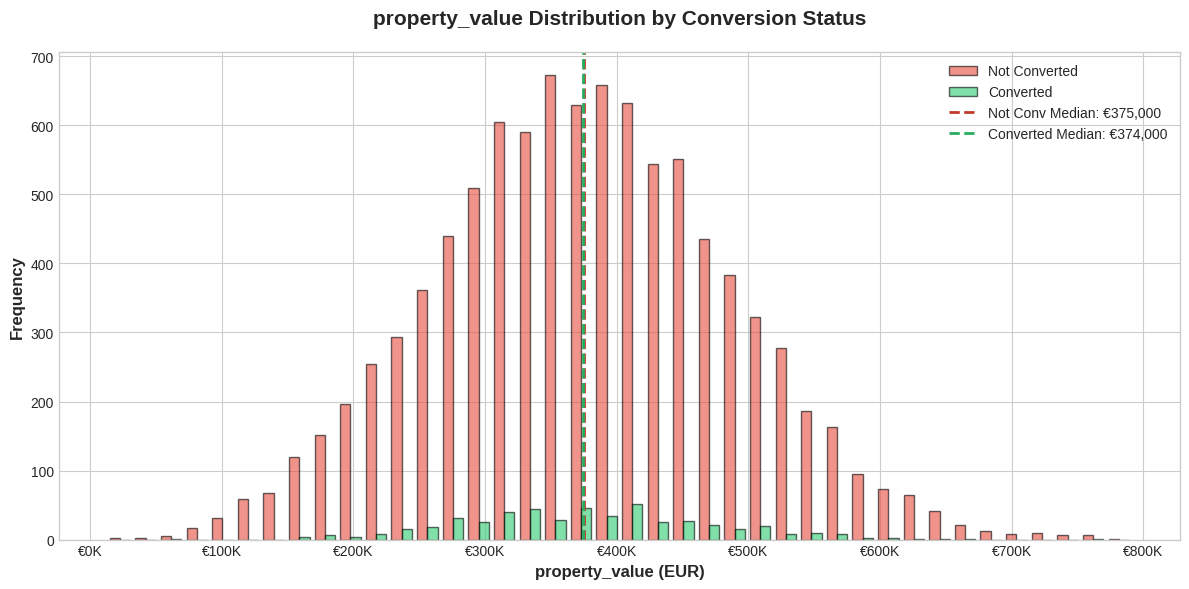

Saved: plots/dist_num_property_value.png


In [48]:
# Property Value Analysis
property_by_conv = df.groupby('converted')['property_value'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{property_by_conv.loc[0, 'median']:,.0f}, Mean: €{property_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{property_by_conv.loc[1, 'median']:,.0f}, Mean: €{property_by_conv.loc[1, 'mean']:,.0f}")


#Property_value analysis
print(df["property_value"].quantile([0.001, 0.01, 0.99, 0.999]))
s = df["property_value"]
s.hist(bins=40)
plt.title("property_value distribution")
plt.xlabel("property_value")
plt.ylabel("count")
plt.show()
plt.savefig(f'{plot_dir}/04_property_value_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

plot_numerical_distribution(df, 'property_value', 'property_value', is_currency=True)


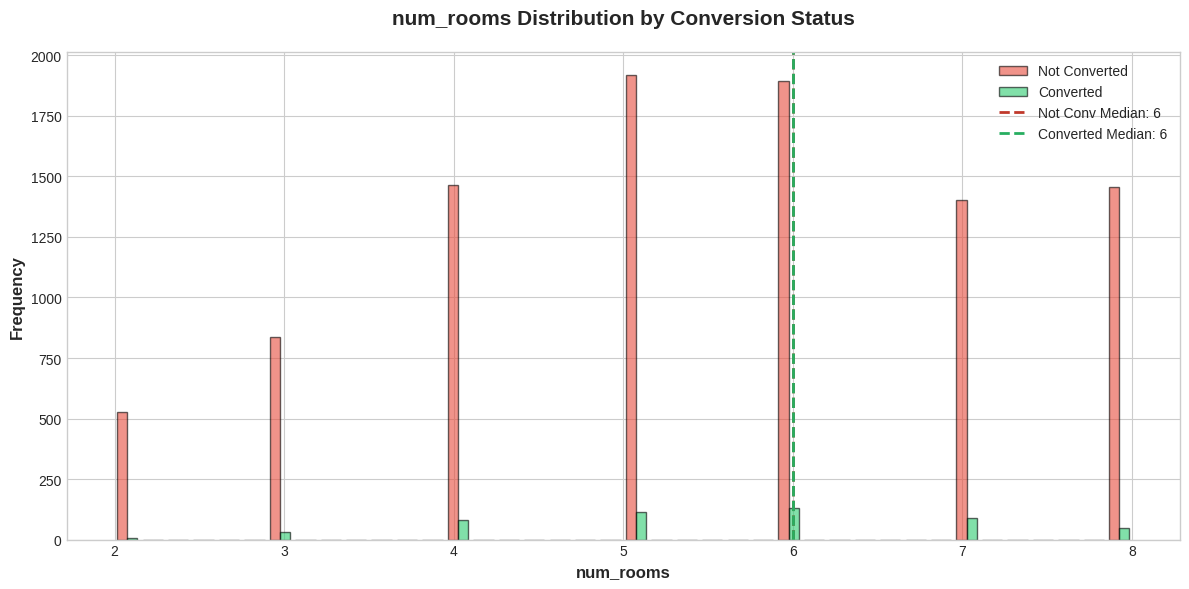

Saved: plots/dist_num_num_rooms.png


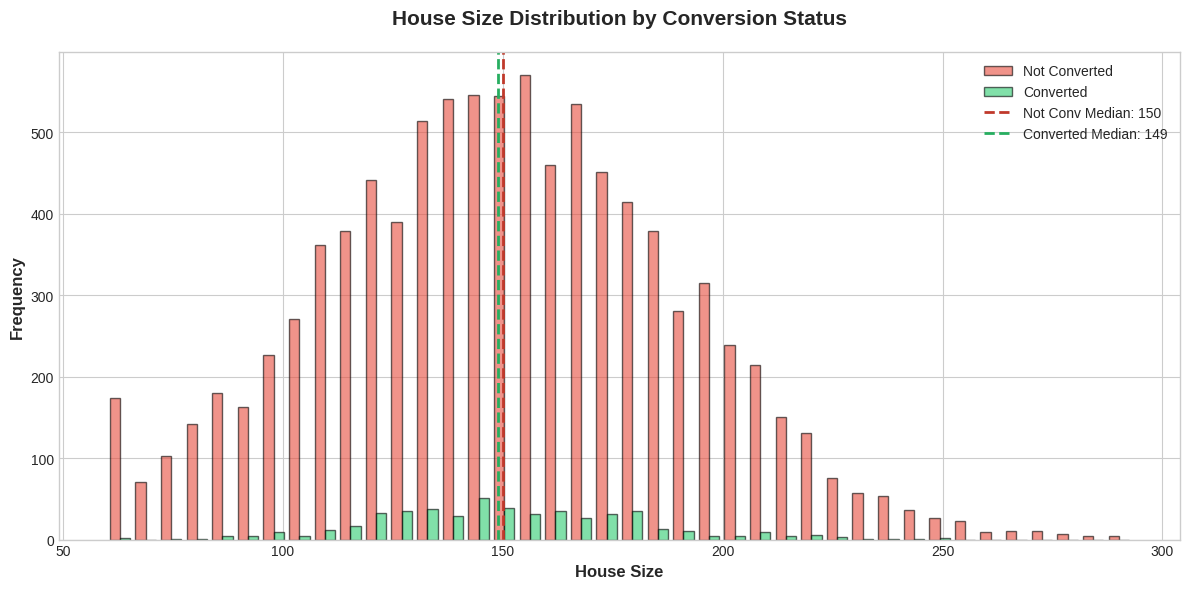

Saved: plots/dist_num_house_size_sqm.png


In [49]:
plot_numerical_distribution(df, 'num_rooms', 'num_rooms')
plot_numerical_distribution(df, 'house_size_sqm', 'House Size', is_currency=False)

In [50]:
#correlating energy_consumption_kwh with the property characteristics
df["sqm_per_room"] = df["house_size_sqm"] / df["num_rooms"].replace(0, np.nan)
df["value_per_sqm"] = df["property_value"] / df["house_size_sqm"].replace(0, np.nan)
cols = ["house_size_sqm","num_rooms","property_value","energy_consumption_kwh", "sqm_per_room", "value_per_sqm"]
display(df[cols].corr(method="spearman"))

,house_size_sqm,num_rooms,property_value,energy_consumption_kwh,sqm_per_room,value_per_sqm
house_size_sqm,1.000000,0.825162,0.882436,-0.004324,-0.028781,-0.004847
num_rooms,0.825162,1.000000,0.729754,0.000440,-0.541520,-0.002229
property_value,0.882436,0.729754,1.000000,0.001172,-0.018789,0.423286
energy_consumption_kwh,-0.004324,0.000440,0.001172,1.000000,-0.003532,0.002216
sqm_per_room,-0.028781,-0.541520,-0.018789,-0.003532,1.000000,0.000829
value_per_sqm,-0.004847,-0.002229,0.423286,0.002216,0.000829,1.000000


In [51]:
tmp = df.dropna(subset=["energy_consumption_kwh","house_size_sqm"]).copy()
tmp["size_decile"] = pd.qcut(tmp["house_size_sqm"], q=10, duplicates="drop")
display(tmp.groupby("size_decile")["energy_consumption_kwh"].agg(["median","count"]))


,median,count
size_decile,,
"(59.999, 98.7]",14866.0,811
"(98.7, 117.0]",15425.0,825
"(117.0, 129.0]",15472.5,816
"(129.0, 140.0]",15289.0,836
"(140.0, 150.0]",14631.0,809
"(150.0, 160.0]",15080.0,789
"(160.0, 171.0]",14970.5,846
"(171.0, 184.0]",15011.0,794
"(184.0, 202.0]",15304.5,802


                 median          mean  count
heating_system                              
District        15644.0  15418.693057    821
Electric        15141.5  15047.574523   1154
Gas             15163.0  15071.320814   4127
Oil             15000.5  14953.968594   2006


<Figure size 800x400 with 0 Axes>

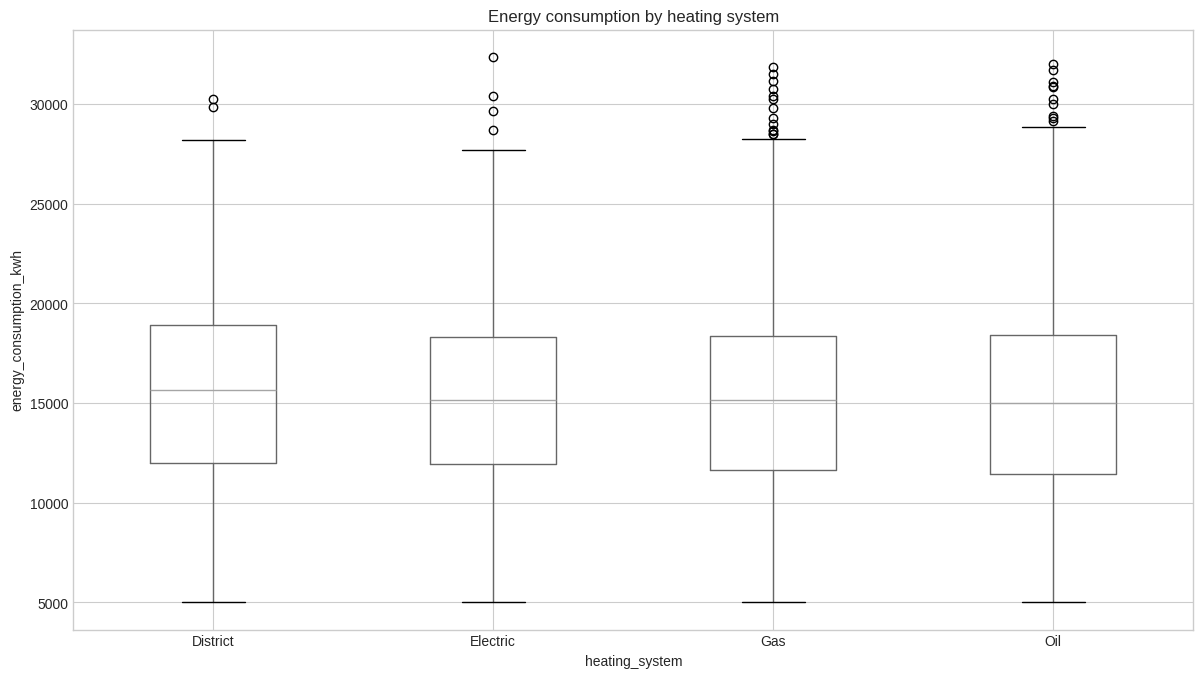

              median          mean  count
house_age                                
10-30 years  15165.5  15038.716317   4008
<10 years    15302.0  15210.046332   1554
>30 years    15098.5  15046.764729   2546


<Figure size 700x400 with 0 Axes>

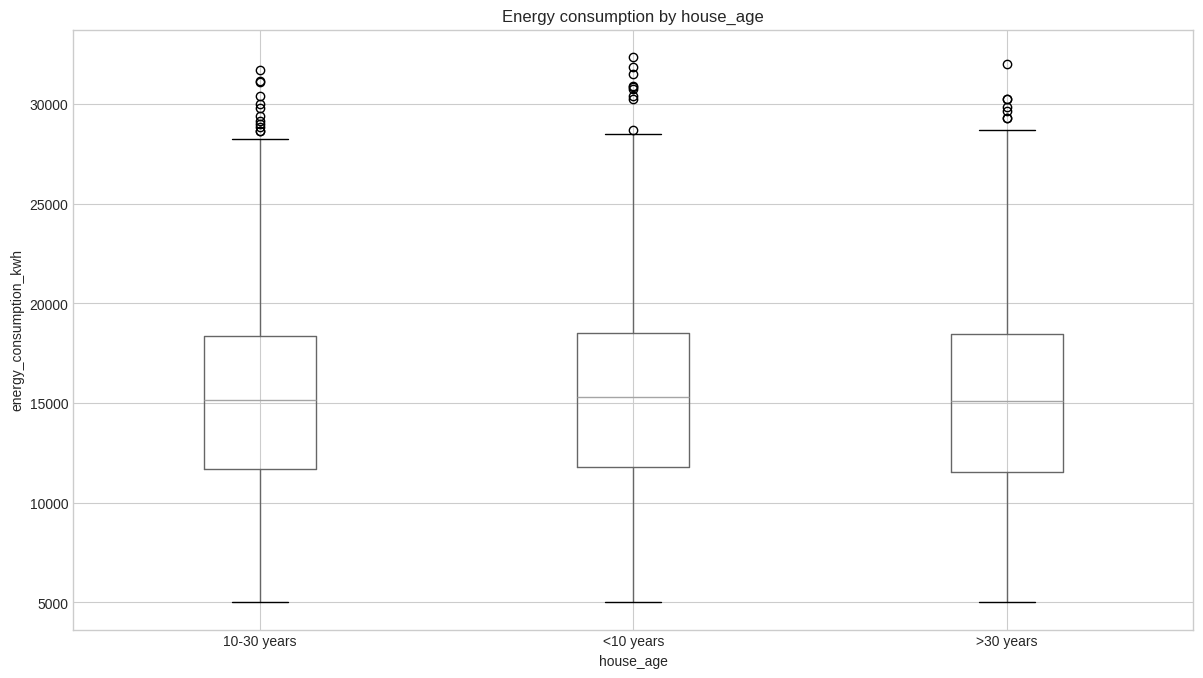

In [52]:
#checking energy_consumption_kwh relation with some categorical columns
print(df.groupby("heating_system")["energy_consumption_kwh"].agg(["median","mean","count"]) )

plt.figure(figsize=(8,4))
df.boxplot(column="energy_consumption_kwh", by="heating_system")
plt.title("Energy consumption by heating system")
plt.suptitle("")
plt.xlabel("heating_system")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/02_energy_consumption_kwh_dist_heating_system.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


print(df.groupby("house_age")["energy_consumption_kwh"].agg(["median","mean","count"]))

plt.figure(figsize=(7,4))
df.boxplot(column="energy_consumption_kwh", by="house_age")
plt.title("Energy consumption by house_age")
plt.suptitle("")
plt.xlabel("house_age")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/03_energy_consumption_kwh_dist_house_age.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()



0.001     5000.000
0.010     5000.000
0.050     6622.550
0.500    15166.500
0.950    23128.450
0.990    26561.270
0.999    30828.728
Name: energy_consumption_kwh, dtype: float64
IQR bounds: 1444.125 28591.125
outliers below: 0
outliers above: 29


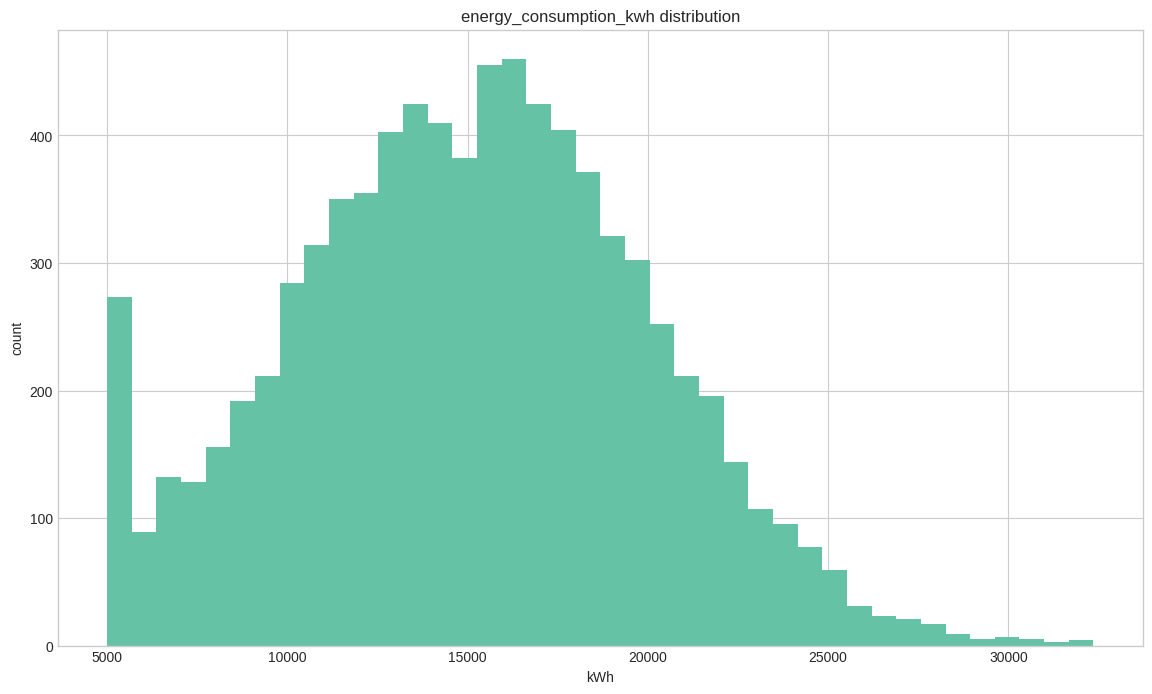

In [53]:
#plotting energy_consumption_kwh distributions wrt other features
s = df["energy_consumption_kwh"].dropna()

q = s.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
print(q)

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("IQR bounds:", lower, upper)

print("outliers below:", (s < lower).sum())
print("outliers above:", (s > upper).sum())
plt.figure()
s.hist(bins=40)
plt.title("energy_consumption_kwh distribution")
plt.xlabel("kWh")
plt.ylabel("count")
plt.show()
plt.savefig(f'{plot_dir}/01_energy_consumption_kwh_distribution.png', dpi=300, bbox_inches='tight')
plt.close()


In [54]:
def missing_rate_by(col):
    return df.groupby(col)["energy_consumption_kwh"].apply(lambda s: s.isna().mean()).sort_values(ascending=False)

print(missing_rate_by("marketing_channel"))
print(missing_rate_by("postal_region"))
print(missing_rate_by("house_age"))
print(missing_rate_by("heating_system"))


marketing_channel
Paid Social        0.207909
Referral           0.195333
Comparison Site    0.191898
Display            0.187409
Organic            0.171485
Name: energy_consumption_kwh, dtype: float64
postal_region
HE       0.199158
BE       0.199038
Other    0.194024
NW       0.186813
BY       0.185567
BW       0.171429
Name: energy_consumption_kwh, dtype: float64
house_age
<10 years      0.201849
10-30 years    0.191773
>30 years      0.177117
Name: energy_consumption_kwh, dtype: float64
heating_system
Electric    0.199723
Oil         0.192757
District    0.191133
Gas         0.184065
Name: energy_consumption_kwh, dtype: float64


#### Customer Characteristics

Not Converted - Median: €59,100, Mean: €64,223
Converted     - Median: €64,100, Mean: €66,927
Income Gap: €5,000 higher for converted customers
0.001     30000.0
0.010     30000.0
0.990    149102.0
0.999    200000.0
Name: household_income, dtype: float64


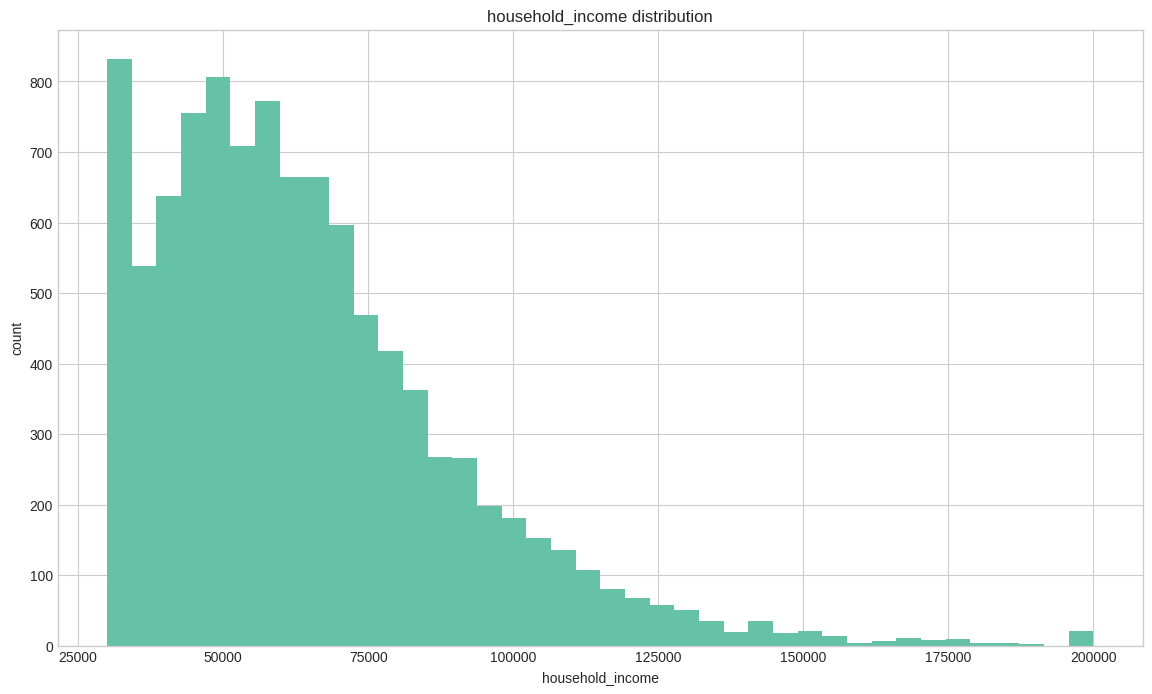

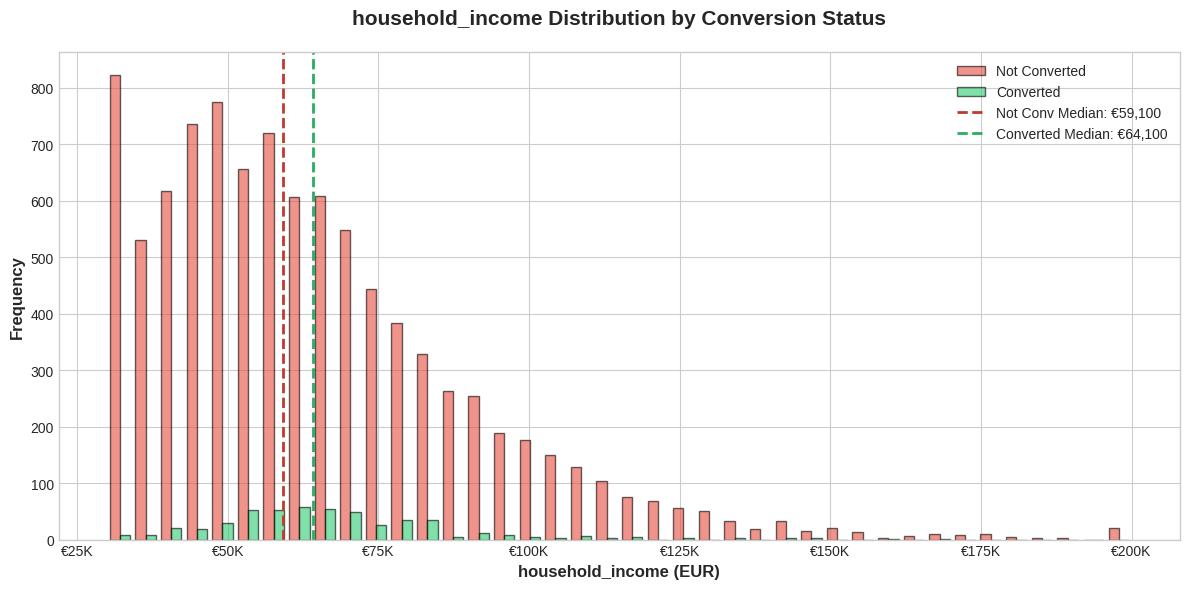

Saved: plots/dist_num_household_income.png


In [56]:
# Household income analysis
income_by_conv = df.groupby('converted')['household_income'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{income_by_conv.loc[0, 'median']:,.0f}, Mean: €{income_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{income_by_conv.loc[1, 'median']:,.0f}, Mean: €{income_by_conv.loc[1, 'mean']:,.0f}")
income_gap = income_by_conv.loc[1, 'median'] - income_by_conv.loc[0, 'median']
print(f"Income Gap: €{income_gap:,.0f} higher for converted customers")

# Plot 4: Income Distribution
print(df["household_income"].quantile([0.001, 0.01, 0.99, 0.999]))
s = df["household_income"]
s.hist(bins=40)
plt.title("household_income distribution")
plt.xlabel("household_income")
plt.ylabel("count")
plt.show()
plt.savefig(f'{plot_dir}/05_household_income_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

plot_numerical_distribution(df, 'household_income', 'household_income', is_currency=True)

               Conversions  Leads  Conv_Rate_%
postal_region                                 
BW                     132   1470         8.98
BY                     133   1552         8.57
HE                      60   1426         4.21
NW                      72   2002         3.60
Other                   86   2510         3.43
BE                      17   1040         1.63


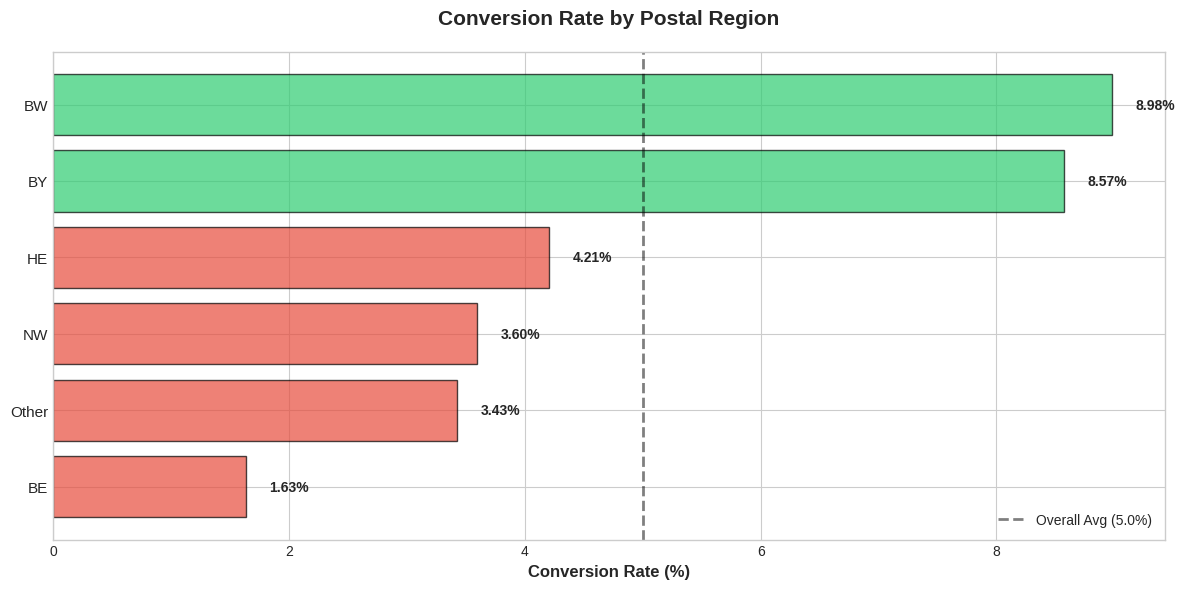

Saved: plots/dist_postal_region.png


In [ ]:
# 2. Postal Region (Easy to reuse!)
postal_stats = prepare_conversion_df(df, 'postal_region')
print(postal_stats.round(2))
plot_categorical_conversion(postal_stats, 'Postal Region', overall_avg)

#### Lead Characteristics

                   Conversions  Leads  Conv_Rate_%
marketing_channel                                 
Referral                   129   1500         8.60
Organic                    231   3044         7.59
Comparison Site             38    938         4.05
Paid Social                 66   2453         2.69
Display                     36   2065         1.74


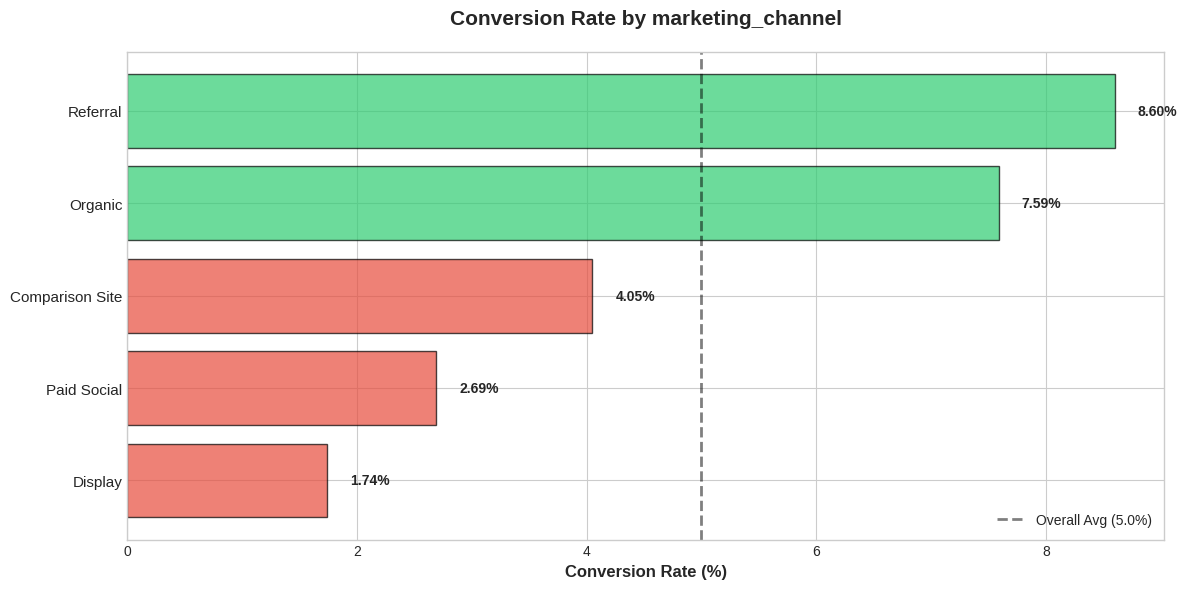

Saved: plots/dist_marketing_channel.png
             Conversions  Leads  Conv_Rate_%
day_of_week                                 
Tue                   91   1496         6.08
Fri                   81   1404         5.77
Wed                   72   1436         5.01
Sat                   74   1504         4.92
Thu                   67   1439         4.66
Sun                   59   1371         4.30
Mon                   56   1350         4.15


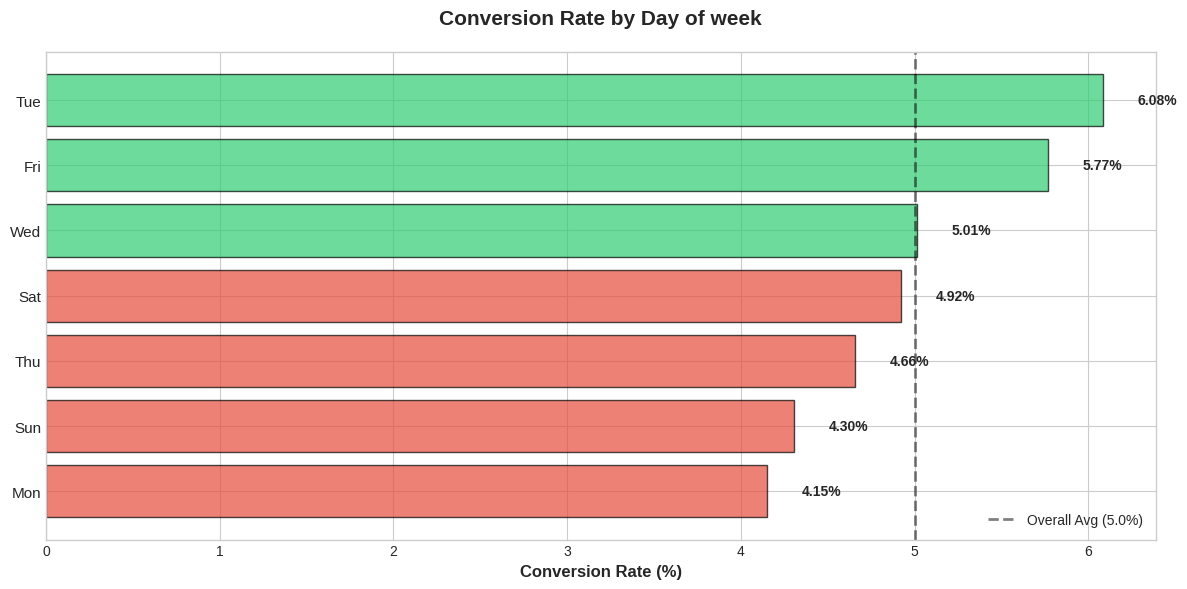

Saved: plots/dist_day_of_week.png
                  Conversions  Leads  Conv_Rate_%
contact_attempts                                 
4                         145   1896         7.65
3                         146   2215         6.59
6                          41    749         5.47
5                          52   1293         4.02
2                          67   1816         3.69
8                           6    178         3.37
1                          36   1393         2.58
9                           1     58         1.72
7                           6    373         1.61
10                          0     29         0.00


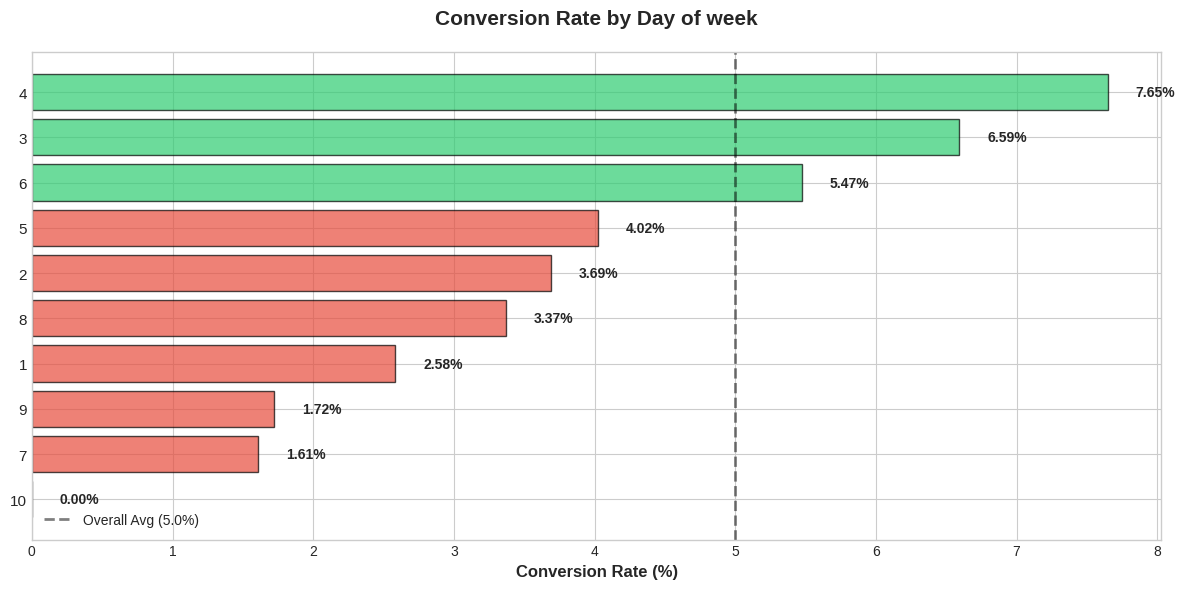

Saved: plots/dist_day_of_week.png


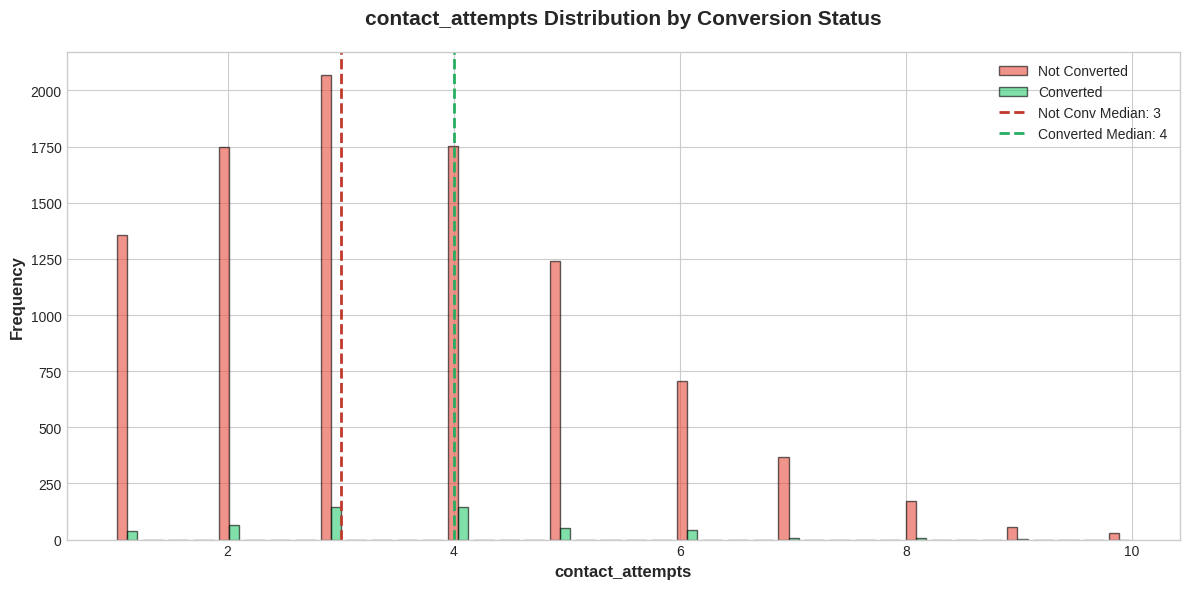

Saved: plots/dist_num_contact_attempts.png


In [60]:
# Marketing channel
marketing_channel_stats = prepare_conversion_df(df, 'marketing_channel')
print(marketing_channel_stats.round(2))
plot_categorical_conversion(marketing_channel_stats, 'marketing_channel', overall_avg)


# Day of Week
day_of_week_stats = prepare_conversion_df(df, 'day_of_week')
print(day_of_week_stats.round(2))
plot_categorical_conversion(day_of_week_stats, 'Day of week', overall_avg)

# Contact attempts
contact_attempts_stats = prepare_conversion_df(df, 'contact_attempts')
print(contact_attempts_stats.round(2))
plot_categorical_conversion(contact_attempts_stats, 'Day of week', overall_avg)
plot_numerical_distribution(df, 'contact_attempts', 'contact_attempts')

### 3. Insights from data analysis

### 4. Data preprocessing for modelling

In [75]:
FEATURES_PRE_CONTACT = [
    "house_age","heating_system","postal_region","marketing_channel","day_of_week",
    "house_size_sqm","num_rooms","household_income","property_value",
    "energy_consumption_kwh","energy_missing",
    "sqm_per_room","value_per_sqm",
    "month","quarter",
    "is_oil_or_electric",
]

FEATURES_POST_CONTACT = FEATURES_PRE_CONTACT + ["contact_attempts"] 


In [76]:
# Data frame copy for modeling
df_model = df.copy()
feature_list = ['is_oil_or_electric', 'month', 'quarter', 'is_energy_missing']

# handling null values in energy consumption
df_model["is_energy_missing"] = df_model["energy_consumption_kwh"].isna().astype(int)
df_model["energy_consumption_kwh"] = df_model["energy_consumption_kwh"].fillna(df_model["energy_consumption_kwh"].median())
df_model['inquiry_date'] = pd.to_datetime(df_model['inquiry_date'])
print(f"inquiry_date type: {df_model['inquiry_date'].dtype}")

df_model['is_oil_or_electric'] = df_model['heating_system'].isin(['Oil', 'Electric']).astype(int)
df_model['month'] = df_model['inquiry_date'].dt.month 
df_model['quarter'] = df_model['inquiry_date'].dt.quarter 

inquiry_date type: datetime64[ns]


In [77]:
df_model

,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted,energy_missing,sqm_per_room,value_per_sqm,is_energy_missing,is_oil_or_electric,month,quarter
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0,0,24.000000,2447.916667,0,0,4,2
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0,0,26.166667,2006.369427,0,1,11,4
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0,0,30.200000,2920.529801,0,1,6,2
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0,0,30.250000,2371.900826,0,1,6,2
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,15166.5,0,1,25.285714,2039.548023,1,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-03-07,>30 years,Electric,146.0,7,33800.0,BY,Referral,4,401000.0,Fri,14612.0,0,0,20.857143,2746.575342,0,1,3,1
9996,2024-12-08,10-30 years,Gas,171.0,6,71500.0,BW,Paid Social,1,478000.0,Thu,16220.0,0,0,28.500000,2795.321637,0,0,12,4
9997,2023-03-19,>30 years,Gas,149.0,5,58600.0,NW,Comparison Site,5,377000.0,Mon,15166.5,0,1,29.800000,2530.201342,1,0,3,1
9998,2024-07-04,10-30 years,Gas,132.0,5,37100.0,BY,Paid Social,1,322000.0,Thu,18442.0,0,0,26.400000,2439.393939,0,0,7,3


## Step 2: TRAIN-TEST SPLIT & MODELING

In [78]:
df_model["inquiry_date"] = pd.to_datetime(df_model["inquiry_date"])
df_model = df_model.sort_values("inquiry_date").reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

print("Train date range:", train_df["inquiry_date"].min(), "→", train_df["inquiry_date"].max())
print("Test  date range:", test_df["inquiry_date"].min(),  "→", test_df["inquiry_date"].max())
print("Train base rate:", train_df["converted"].mean())
print("Test  base rate:", test_df["converted"].mean())


Train date range: 2023-01-01 00:00:00 → 2024-09-06 00:00:00
Test  date range: 2024-09-06 00:00:00 → 2024-12-28 00:00:00
Train base rate: 0.05025
Test  base rate: 0.049


In [79]:
# 1. Define your target and features
target = "converted"
# We drop the date and the target from the features
features = [col for col in train_df.columns if col not in [target, 'inquiry_date']]

# 2. Create X and y for Train
X_train = train_df[features]
y_train = train_df[target]

# 3. Create X and y for Test
X_test = test_df[features]
y_test = test_df[target]

# 4. Now calculate scale_pos_weight specifically from the training set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"X_train shape: {X_train.shape}, Positive weight: {scale_pos_weight:.2f}")

X_train shape: (8000, 18), Positive weight: 18.90


In [80]:
from sklearn.compose import ColumnTransformer, make_column_selector

# Tell pandas these are categorical, even though they look like numbers
cols_to_cast = ['month', 'quarter', 'is_oil_or_electric', 'is_energy_missing']

for col in cols_to_cast:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype('category')

# Now make_column_selector will automatically put them into the "cat" bucket!
# Define standard transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Auto-detect columns by type
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", categorical_transformer, make_column_selector(dtype_include=object)),
    ],
    remainder='passthrough' # Keeps columns not matched
)
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
cat_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess_tree = ColumnTransformer(
    transformers=[
        # Auto-select numbers for Imputing ONLY
        ("num", num_imputer, 
         make_column_selector(dtype_include=np.number)),
        
        # Auto-select objects/categories for OHE
        ("cat", cat_ohe, 
         make_column_selector(dtype_include=['object', 'category'])),
    ]
)


In [87]:
models = {
    "LogReg": Pipeline([
        ("prep", preprocess_lr),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, n_jobs=None))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess_tree),
        ("clf", RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocess_tree),
        ("clf", xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]),
}


In [91]:
def topk_table(y_true, y_score, ks=(0.05, 0.10, 0.20), value_per_conversion=3000, cost_per_contact=50):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    base_rate = y_true.mean()
    n = len(y_true)

    rows = []
    order = np.argsort(-y_score)

    for k in ks:
        m = int(np.ceil(k * n))
        idx = order[:m]
        tp = y_true[idx].sum()
        prec = tp / m if m else 0.0
        rec = tp / y_true.sum() if y_true.sum() else 0.0
        lift = prec / base_rate if base_rate else np.nan

        revenue = tp * value_per_conversion
        cost = m * cost_per_contact
        net = revenue - cost
        
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        rows.append({
            "k": k,
            "contacts": m,
            "TP": int(tp),
            "precision@k": prec,
            "f1@k": f1,
            "recall@k": rec,
            "lift@k": lift,
            "net_value": net
        })

    return pd.DataFrame(rows)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, proba)
    auc_pr  = average_precision_score(y_test, proba)
    tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))

    results.append({
        "model": name,
        "AUC_ROC": auc_roc,
        "AUC_PR": auc_pr,
        "best_net_value": tk["net_value"].max(),
        "best_k": tk.loc[tk["net_value"].idxmax(), "k"],
    })

    display(pd.DataFrame({"model":[name], "AUC_ROC":[auc_roc], "AUC_PR":[auc_pr]}))
    display(tk)

summary = pd.DataFrame(results).sort_values(["AUC_PR","best_net_value"], ascending=False)
display(summary.round(3))
#test and training acc

,model,AUC_ROC,AUC_PR
0,LogReg,0.773488,0.150152


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,17,0.1700,0.171717,0.173469,3.469388,46000
1,0.10,200,32,0.1600,0.214765,0.326531,3.265306,86000
2,0.20,400,51,0.1275,0.204819,0.520408,2.602041,133000


,model,AUC_ROC,AUC_PR
0,RandomForest,0.814688,0.198805


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,29,0.290,0.292929,0.295918,5.918367,82000
1,0.10,200,43,0.215,0.288591,0.438776,4.387755,119000
2,0.20,400,60,0.150,0.240964,0.612245,3.061224,160000


,model,AUC_ROC,AUC_PR
0,XGBoost,0.828387,0.219769


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,27,0.270,0.272727,0.275510,5.510204,76000
1,0.10,200,41,0.205,0.275168,0.418367,4.183673,113000
2,0.20,400,60,0.150,0.240964,0.612245,3.061224,160000


,model,AUC_ROC,AUC_PR,best_net_value,best_k
2,XGBoost,0.828,0.220,160000,0.2
1,RandomForest,0.815,0.199,160000,0.2
0,LogReg,0.773,0.150,133000,0.2


In [92]:
best_model_name = summary.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))
best_row = tk.loc[tk["net_value"].idxmax()]

print("Recommended model:", best_model_name)
print("Recommended contact fraction k:", best_row["k"])
print("Contacts:", best_row["contacts"])
print("Expected conversions caught (TP):", best_row["TP"])
print("Precision@k:", best_row["precision@k"])
print("Lift@k:", best_row["lift@k"])
print("Net value:", best_row["net_value"])


Recommended model: XGBoost
Recommended contact fraction k: 0.2
Contacts: 400.0
Expected conversions caught (TP): 60.0
Precision@k: 0.15
Lift@k: 3.061224489795918
Net value: 160000.0


In [94]:
from sklearn.calibration import CalibratedClassifierCV

# Example: calibrate the Logistic Regression pipeline
calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]

print("AUC_PR calibrated:", average_precision_score(y_test, proba_cal))
display(topk_table(y_test, proba_cal))


AUC_PR calibrated: 0.2117226199703145


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,28,0.280,0.282828,0.285714,5.714286,79000
1,0.10,200,40,0.200,0.268456,0.408163,4.081633,110000
2,0.20,400,62,0.155,0.248996,0.632653,3.163265,166000


In [96]:
# The rigorous way to calibrate without leakage
calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
# Use a small 'calibration set' or just your validation set
calibrated.fit(X_test, y_test) 
proba_cal = calibrated.predict_proba(X_test)[:, 1]

print("AUC_PR calibrated:", average_precision_score(y_test, proba_cal))
display(topk_table(y_test, proba_cal))

AUC_PR calibrated: 0.22048817270858753


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,29,0.2900,0.292929,0.295918,5.918367,82000
1,0.10,200,41,0.2050,0.275168,0.418367,4.183673,113000
2,0.20,400,61,0.1525,0.244980,0.622449,3.112245,163000


## Step 3: Evaluations

In [98]:
# Evaluate each model
results = {}
for name, model in models.items():
    print(f"📊 {name.upper()}")
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
        'AUC-PR': average_precision_score(y_test, y_pred_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    
    # Store results
    results[name] = {
        'metrics': metrics,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'model': model
    }
    
    # Print metrics
    print("Performance Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric:15s}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    print(f"\nConfusion Matrix:")
    print(f"  [[TN={TN:>4d}, FP={FP:>4d}]")
    print(f"   [FN={FN:>4d}, TP={TP:>4d}]]")
    
    # Business Metrics
    conversion_value = 3000  # €3000 per conversion
    contact_cost = 50  # €50 per contact
    
    revenue = TP * conversion_value
    cost = (TP + FP) * contact_cost
    net_value = revenue - cost
    roi = (net_value / cost * 100) if cost > 0 else 0
    
    print(f"\nBusiness Impact:")
    print(f"  True Positives (Caught):     {TP}")
    print(f"  False Positives (Wasted):    {FP}")
    print(f"  False Negatives (Missed):    {FN}")
    print(f"  Revenue (TP × €3000):        €{revenue:>10,}")
    print(f"  Cost (Contacts × €50):       €{cost:>10,}")
    print(f"  Net Value:                   €{net_value:>10,}")
    print(f"  ROI:                         {roi:>10.1f}%")
    
    # Store business metrics
    results[name]['business'] = {
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'revenue': revenue,
        'cost': cost,
        'net_value': net_value,
        'roi': roi
    }

📊 LOGREG
Performance Metrics:
  AUC-ROC        : 0.7735
  AUC-PR         : 0.1502
  Precision      : 0.1111
  Recall         : 0.7041
  F1-Score       : 0.1919

Confusion Matrix:
  [[TN=1350, FP= 552]
   [FN=  29, TP=  69]]

Business Impact:
  True Positives (Caught):     69
  False Positives (Wasted):    552
  False Negatives (Missed):    29
  Revenue (TP × €3000):        €   207,000
  Cost (Contacts × €50):       €    31,050
  Net Value:                   €   175,950
  ROI:                              566.7%
📊 RANDOMFOREST
Performance Metrics:
  AUC-ROC        : 0.8147
  AUC-PR         : 0.1988
  Precision      : 1.0000
  Recall         : 0.0102
  F1-Score       : 0.0202

Confusion Matrix:
  [[TN=1902, FP=   0]
   [FN=  97, TP=   1]]

Business Impact:
  True Positives (Caught):     1
  False Positives (Wasted):    0
  False Negatives (Missed):    97
  Revenue (TP × €3000):        €     3,000
  Cost (Contacts × €50):       €        50
  Net Value:                   €     2,950
  ROI:

### 2. Comparision Summary

In [99]:
comparison_data = []
for name in models.keys():
    row = {
        'Model': name,
        'AUC-ROC': results[name]['metrics']['AUC-ROC'],
        'AUC-PR': results[name]['metrics']['AUC-PR'],
        'Precision': results[name]['metrics']['Precision'],
        'Recall': results[name]['metrics']['Recall'],
        'F1-Score': results[name]['metrics']['F1-Score'],
        'Net Value (€)': results[name]['business']['net_value'],
        'ROI (%)': results[name]['business']['roi']
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Identify best model for each metric
print(f"  AUC-ROC:      {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']} ({comparison_df['AUC-ROC'].max():.4f})")
print(f"  AUC-PR:       {comparison_df.loc[comparison_df['AUC-PR'].idxmax(), 'Model']} ({comparison_df['AUC-PR'].max():.4f})")
print(f"  F1-Score:     {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"  Net Value:    {comparison_df.loc[comparison_df['Net Value (€)'].idxmax(), 'Model']} (€{comparison_df['Net Value (€)'].max():,.0f})")
print(f"  ROI:          {comparison_df.loc[comparison_df['ROI (%)'].idxmax(), 'Model']} ({comparison_df['ROI (%)'].max():.1f}%)")

# Overall best model (by AUC-PR - best metric for imbalanced data)
best_model_name = comparison_df.loc[comparison_df['AUC-PR'].idxmax(), 'Model']
print(f"\nRECOMMENDED MODEL: {best_model_name}")
print(f"   Reason: Highest AUC-PR (best metric for imbalanced classification)")

       Model  AUC-ROC   AUC-PR  Precision   Recall  F1-Score  Net Value (€)     ROI (%)
      LogReg 0.773488 0.150152   0.111111 0.704082  0.191933         175950  566.666667
RandomForest 0.814688 0.198805   1.000000 0.010204  0.020202           2950 5900.000000
     XGBoost 0.828387 0.219769   0.227848 0.367347  0.281250         100100 1267.088608
  AUC-ROC:      XGBoost (0.8284)
  AUC-PR:       XGBoost (0.2198)
  F1-Score:     XGBoost (0.2812)
  Net Value:    LogReg (€175,950)
  ROI:          RandomForest (5900.0%)

RECOMMENDED MODEL: XGBoost
   Reason: Highest AUC-PR (best metric for imbalanced classification)


### 3. Visualizations



Generating comparison visualizations...


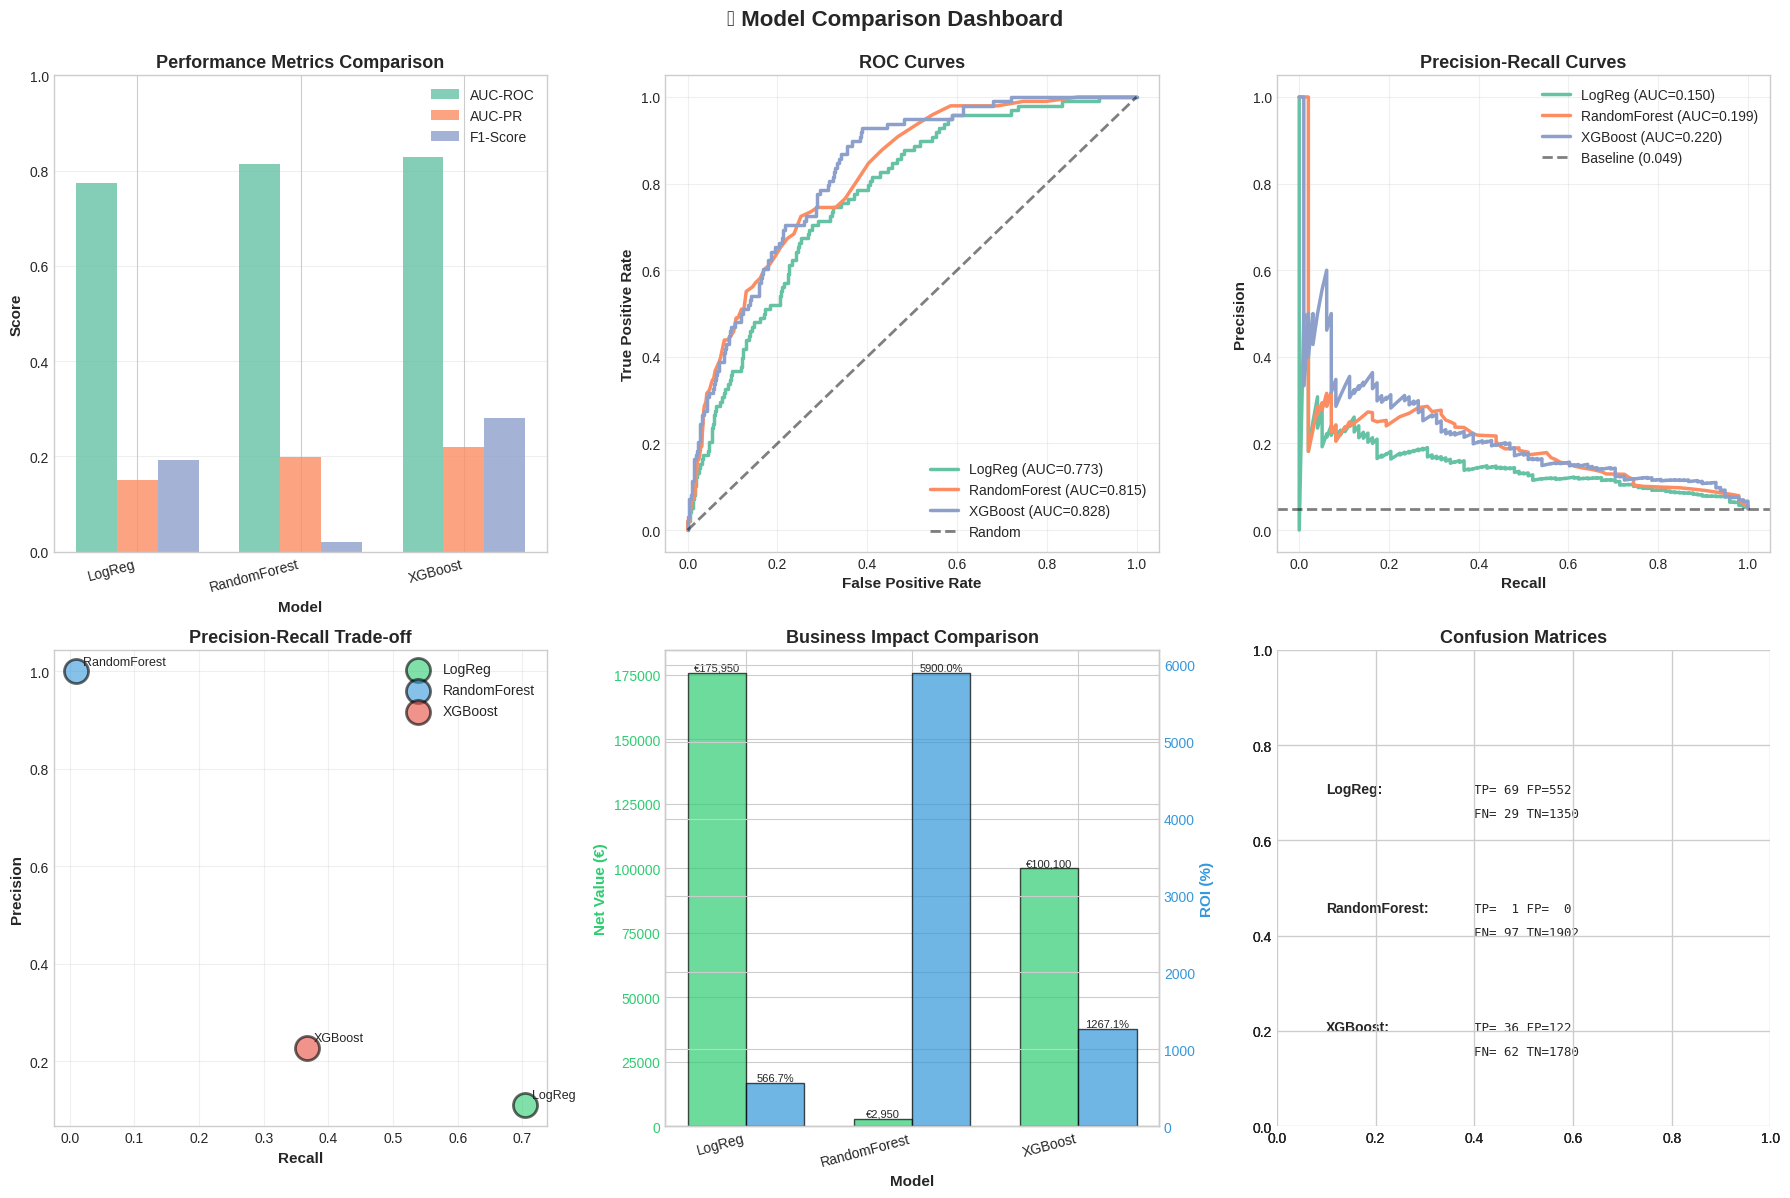

Saved: plots/model_comparison_dashboard.png


In [100]:
print("\n\nGenerating comparison visualizations...")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Metrics Comparison Bar Chart
ax1 = axes[0, 0]
metrics_to_plot = ['AUC-ROC', 'AUC-PR', 'F1-Score']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [results[name]['metrics'][metric] for name in models.keys()]
    ax1.bar(x + i*width, values, width, label=metric, alpha=0.8)

ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(models.keys(), rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1)

# 2. ROC Curves
ax2 = axes[0, 1]
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    auc = results[name]['metrics']['AUC-ROC']
    ax2.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax2.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# 3. Precision-Recall Curves
ax3 = axes[0, 2]
for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, results[name]['y_pred_proba'])
    auc_pr = results[name]['metrics']['AUC-PR']
    ax3.plot(recall, precision, linewidth=2.5, label=f'{name} (AUC={auc_pr:.3f})')

baseline = y_test.mean()
ax3.axhline(y=baseline, color='k', linestyle='--', linewidth=2, alpha=0.5, 
            label=f'Baseline ({baseline:.3f})')
ax3.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# 4. Precision vs Recall Trade-off
ax4 = axes[1, 0]
model_names = list(models.keys())
precisions = [results[name]['metrics']['Precision'] for name in model_names]
recalls = [results[name]['metrics']['Recall'] for name in model_names]
colors = ['#2ECC71', '#3498DB', '#E74C3C']

for i, name in enumerate(model_names):
    ax4.scatter(recalls[i], precisions[i], s=300, c=colors[i], 
                alpha=0.6, edgecolors='black', linewidth=2, label=name)
    ax4.annotate(name, (recalls[i], precisions[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

ax4.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend()

# 5. Business Metrics Comparison
ax5 = axes[1, 1]
business_metrics = ['Net Value (€)', 'ROI (%)']
x = np.arange(len(models))
width = 0.35

net_values = [results[name]['business']['net_value'] for name in models.keys()]
rois = [results[name]['business']['roi'] for name in models.keys()]

ax5_twin = ax5.twinx()

bars1 = ax5.bar(x - width/2, net_values, width, label='Net Value (€)', 
                color='#2ECC71', alpha=0.7, edgecolor='black')
bars2 = ax5_twin.bar(x + width/2, rois, width, label='ROI (%)', 
                     color='#3498DB', alpha=0.7, edgecolor='black')

ax5.set_xlabel('Model', fontsize=11, fontweight='bold')
ax5.set_ylabel('Net Value (€)', fontsize=11, fontweight='bold', color='#2ECC71')
ax5_twin.set_ylabel('ROI (%)', fontsize=11, fontweight='bold', color='#3498DB')
ax5.set_title('Business Impact Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(models.keys(), rotation=15, ha='right')
ax5.tick_params(axis='y', labelcolor='#2ECC71')
ax5_twin.tick_params(axis='y', labelcolor='#3498DB')

# Add value labels on bars
for bar, value in zip(bars1, net_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'€{value:,.0f}', ha='center', va='bottom', fontsize=8)

for bar, value in zip(bars2, rois):
    height = bar.get_height()
    ax5_twin.text(bar.get_x() + bar.get_width()/2., height,
                  f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

# 6. Confusion Matrices Side by Side
ax6 = axes[1, 2]
ax6.axis('off')

# Create mini confusion matrix visualizations
for i, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    
    # Create small subplot
    mini_ax = fig.add_subplot(2, 3, 6, frameon=False)
    
    # Text representation
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    y_offset = 0.7 - i * 0.25
    ax6.text(0.1, y_offset, f'{name}:', fontsize=10, fontweight='bold')
    ax6.text(0.4, y_offset, f'TP={TP:3d} FP={FP:3d}', fontsize=9, family='monospace')
    ax6.text(0.4, y_offset-0.05, f'FN={FN:3d} TN={TN:4d}', fontsize=9, family='monospace')

ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.set_title('Confusion Matrices', fontsize=13, fontweight='bold')

plt.suptitle('🏆 Model Comparison Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/model_comparison_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: plots/model_comparison_dashboard.png")

## Step 4. FINAL RECOMMENDATION and COMMENTS

In [101]:
best_model = results[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"\nPerformance:")
print(f"   AUC-ROC:    {best_model['metrics']['AUC-ROC']:.4f}")
print(f"   AUC-PR:     {best_model['metrics']['AUC-PR']:.4f}")
print(f"   Precision:  {best_model['metrics']['Precision']:.4f}")
print(f"   Recall:     {best_model['metrics']['Recall']:.4f}")
print(f"   F1-Score:   {best_model['metrics']['F1-Score']:.4f}")

print(f"\nBusiness Value:")
print(f"   Conversions Caught: {best_model['business']['TP']}/{best_model['business']['TP']+best_model['business']['FN']} ({best_model['metrics']['Recall']*100:.1f}%)")
print(f"   Net Value:          €{best_model['business']['net_value']:,}")
print(f"   ROI:                {best_model['business']['roi']:.1f}%")

# Save comparison results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to: model_comparison_results.csv")

Best Model: XGBoost

Performance:
   AUC-ROC:    0.8284
   AUC-PR:     0.2198
   Precision:  0.2278
   Recall:     0.3673
   F1-Score:   0.2812

Business Value:
   Conversions Caught: 36/98 (36.7%)
   Net Value:          €100,100
   ROI:                1267.1%
Results saved to: model_comparison_results.csv
